# Amazon Sum-vs-CAMA Fix: Custom SumAggregation Bypassing pyg-lib Fused Path

**GPU experiment on rel-amazon/item-ltv** comparing sum vs mean vs CAMA aggregation in HeteroGraphSAGE.

**Key innovation**: `SafeSumAggregation` bypasses pyg-lib's fused spmm path (fixing iter-6 failure) by being an `Aggregation` *object* (not a string), so `SAGEConv.fuse=False`.

**Results** (from pre-computed experiment):
- CAMA MAE=46.97±0.05 (best)
- Sum MAE=47.33±0.38
- Mean MAE=51.80±0.39
- Cohen's d: CAMA vs sum=1.21, CAMA vs mean=17.28, sum vs mean=11.61

This notebook demonstrates the aggregation classes, runs unit tests, performs statistical analysis on pre-computed results, and visualizes the findings.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are from core packages

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, pandas==2.2.2, scipy==1.16.3, matplotlib==3.10.0, torch==2.9.0
    _v = sys.version_info
    if _v >= (3, 12):
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')
        _pip('torch==2.9.0+cpu', '--index-url', 'https://download.pytorch.org/whl/cpu')
    else:
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.15.3', 'matplotlib==3.10.0')
        _pip('torch==2.5.1+cpu', '--index-url', 'https://download.pytorch.org/whl/cpu')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import copy
import time
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
    print(f"PyTorch {torch.__version__} available")
except ImportError:
    HAS_TORCH = False
    print("PyTorch not available — aggregation unit tests will be skipped")

PyTorch 2.5.1+cpu available


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter7_amazon_sum_vs_c/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data: {data['title']}")
print(f"Methods tested: {data['methods_tested']}")
print(f"Number of runs: {len(data['all_run_results'])}")
print(f"Key findings: {data['key_findings']}")

Loaded data: Amazon Sum-vs-CAMA Fix + Trial Classification: Custom SumAggregation Bypassing pyg-lib Fused Path
Methods tested: ['sum', 'mean', 'cama']
Number of runs: 10
Key findings: ['CAMA outperforms sum on rel-amazon__item-ltv (mae): d=1.205', 'CAMA vs mean on rel-amazon__item-ltv: d=17.280', 'Sum vs mean on rel-amazon__item-ltv: d=11.611']


## Configuration

Tunable parameters for the demo. These control the scale of the unit tests and statistical analysis.

In [5]:
# --- Tunable parameters ---
# Unit test dimensions
CHANNELS = 128        # Hidden dimension for aggregation tests
N_TEST_NODES = 100    # Number of input nodes in unit tests
N_GROUPS = 10         # Number of target groups in unit tests

# Statistical analysis
N_BOOTSTRAP = 10000   # Bootstrap iterations for confidence intervals

## Custom Aggregation Classes

The core innovation: `SafeSumAggregation` and `CAMAAggregation` (Cardinality-Aware Moment Aggregation).

- **SafeSumAggregation**: By being an `nn.Module` (not a string `"sum"`), when passed to `SAGEConv(aggr=...)`, PyG sets `fuse=False`, bypassing the `message_and_aggregate()` path that calls `spmm()` requiring pyg-lib.
- **CAMAAggregation**: Enriches mean aggregation with per-dimension variance, gated by log-cardinality. A simplified version of RAMA.

Below we implement standalone versions using pure PyTorch scatter operations (no torch_geometric dependency).

In [6]:
if HAS_TORCH:
    # ============================================================================
    # Helper: scatter reduce (replaces torch_geometric's Aggregation.reduce)
    # ============================================================================
    def scatter_reduce(x, index, dim_size, reduce='sum'):
        """Pure PyTorch scatter reduce along dim=0."""
        if dim_size is None:
            dim_size = int(index.max()) + 1 if index is not None and index.numel() > 0 else 0
        out = torch.zeros(dim_size, x.size(-1), device=x.device, dtype=x.dtype)
        idx = index.unsqueeze(1).expand(-1, x.size(-1))
        if reduce == 'sum':
            return out.scatter_add_(0, idx, x)
        elif reduce == 'mean':
            out.scatter_add_(0, idx, x)
            count = torch.zeros(dim_size, 1, device=x.device, dtype=x.dtype)
            count.scatter_add_(0, index.unsqueeze(1), torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype))
            count = count.clamp(min=1)
            return out / count
        else:
            raise ValueError(f"Unknown reduce: {reduce}")

    # ============================================================================
    # STEP 4: CUSTOM SAFE SUM AGGREGATION - THE CRITICAL FIX
    # ============================================================================
    class SafeSumAggregation(nn.Module):
        """Sum aggregation as a custom nn.Module subclass.

        CRITICAL: By being an nn.Module *object* (not a string), when passed
        to SAGEConv(aggr=SafeSumAggregation()), PyG's MessagePassing checks
        isinstance(self.aggr, str) -> False -> self.fuse = False -> bypasses
        message_and_aggregate() which calls spmm() requiring pyg-lib.
        """

        def forward(self, x, index=None, dim_size=None):
            return scatter_reduce(x, index, dim_size, reduce='sum')

    class PureTorchSumAggregation(nn.Module):
        """Fallback sum aggregation using pure PyTorch (no torch_scatter needed)."""

        def forward(self, x, index=None, dim_size=None):
            if dim_size is None:
                dim_size = int(index.max()) + 1 if index is not None and index.numel() > 0 else 0
            out = torch.zeros(dim_size, x.size(-1), device=x.device, dtype=x.dtype)
            if index is not None:
                return out.index_add_(0, index, x)
            return out

    # ============================================================================
    # STEP 5: CAMA AGGREGATION
    # ============================================================================
    class CAMAAggregation(nn.Module):
        """Cardinality-Aware Moment Aggregation.

        Enriches mean with per-dimension variance, gated by log-cardinality.
        Simplified RAMA: gate depends ONLY on log(cardinality), no rank proxy.
        """

        def __init__(self, channels: int):
            super().__init__()
            self.channels = channels
            self.gate_net = nn.Linear(1, channels, bias=True)
            self.var_transform = nn.Linear(channels, channels, bias=False)
            self._gate_buffer: list = []
            self._recording = False
            self.reset_parameters()

        def reset_parameters(self):
            nn.init.zeros_(self.gate_net.weight)
            nn.init.zeros_(self.gate_net.bias)
            nn.init.eye_(self.var_transform.weight)

        def forward(self, x, index=None, dim_size=None):
            mean = scatter_reduce(x, index, dim_size, reduce='mean')
            mean_of_sq = scatter_reduce(x * x, index, dim_size, reduce='mean')
            var = (mean_of_sq - mean * mean).clamp(min=1e-8)

            ones = x.new_ones(x.size(0), 1)
            cardinality = scatter_reduce(ones, index, dim_size, reduce='sum')
            log_card = torch.log1p(cardinality)

            gate = torch.sigmoid(self.gate_net(log_card))

            if self._recording:
                self._gate_buffer.append(gate.detach().cpu())

            return mean + gate * self.var_transform(var)

        def start_recording(self):
            self._recording = True
            self._gate_buffer = []

        def stop_recording(self) -> Optional[Dict[str, float]]:
            self._recording = False
            if self._gate_buffer:
                all_gates = torch.cat(self._gate_buffer, dim=0)
                self._gate_buffer = []
                if all_gates.numel() == 0:
                    return None
                return {
                    'mean': float(all_gates.mean()),
                    'std': float(all_gates.std()),
                    'min': float(all_gates.min()),
                    'max': float(all_gates.max()),
                    'median': float(all_gates.median()),
                }
            return None

    print("Aggregation classes defined.")
else:
    print("Skipping aggregation class definitions (requires PyTorch).")

Aggregation classes defined.


## Unit Tests for Aggregation Classes

Verify correctness, gradient flow, and gate initialization of the custom aggregations.

In [7]:
if HAS_TORCH:
    # Test 1: SafeSumAggregation
    print("Test 1: SafeSumAggregation...")
    sum_agg = SafeSumAggregation()
    x_test = torch.randn(N_TEST_NODES, CHANNELS, requires_grad=True)
    index_test = torch.randint(0, N_GROUPS, (N_TEST_NODES,))
    out_test = sum_agg(x_test, index=index_test, dim_size=N_GROUPS)
    assert out_test.shape == (N_GROUPS, CHANNELS), f"Expected ({N_GROUPS},{CHANNELS}), got {out_test.shape}"

    # Verify numerical correctness against manual scatter_add
    with torch.no_grad():
        expected = torch.zeros(N_GROUPS, CHANNELS).scatter_add_(
            0, index_test.unsqueeze(1).expand(-1, CHANNELS), x_test.detach()
        )
    assert torch.allclose(out_test.detach(), expected, atol=1e-5), "SafeSumAggregation incorrect!"

    # Gradient flow
    loss_test = out_test.sum()
    loss_test.backward()
    assert x_test.grad is not None, "No gradient for input x through SafeSumAggregation"
    print(f"  Shape OK: {out_test.shape}, Numerical OK, Gradient OK")

    # Test 2: CAMA
    print("\nTest 2: CAMAAggregation...")
    cama_test = CAMAAggregation(channels=CHANNELS)
    x_test2 = torch.randn(N_TEST_NODES, CHANNELS, requires_grad=True)
    out_test = cama_test(x_test2, index=index_test, dim_size=N_GROUPS)
    assert out_test.shape == (N_GROUPS, CHANNELS), f"Expected ({N_GROUPS},{CHANNELS}), got {out_test.shape}"
    loss_test = out_test.sum()
    loss_test.backward()
    for name, p in cama_test.named_parameters():
        assert p.grad is not None, f"No gradient for {name}"
    print(f"  Shape OK: {out_test.shape}, Gradient OK for all parameters")

    # Test gate recording
    cama_test.start_recording()
    cama_test.zero_grad()
    _ = cama_test(x_test2.detach(), index=index_test, dim_size=N_GROUPS)
    gs = cama_test.stop_recording()
    assert gs is not None, "Gate recording failed"
    assert abs(gs['mean'] - 0.5) < 0.05, f"Initial gate should be ~0.5, got {gs['mean']}"
    print(f"  Gate init mean={gs['mean']:.4f} (expected ~0.5)")
    print(f"  Gate stats: {gs}")

    # Test 3: PureTorchSumAggregation
    print("\nTest 3: PureTorchSumAggregation...")
    pt_sum = PureTorchSumAggregation()
    out_pt = pt_sum(x_test.detach(), index=index_test, dim_size=N_GROUPS)
    assert torch.allclose(out_pt, expected, atol=1e-5), "PureTorchSumAggregation incorrect!"
    print(f"  Shape OK: {out_pt.shape}, Numerical OK (matches SafeSumAggregation)")

    print("\nAll unit tests passed!")
else:
    print("Skipping unit tests (requires PyTorch).")

Test 1: SafeSumAggregation...
  Shape OK: torch.Size([10, 128]), Numerical OK, Gradient OK

Test 2: CAMAAggregation...
  Shape OK: torch.Size([10, 128]), Gradient OK for all parameters
  Gate init mean=0.5000 (expected ~0.5)
  Gate stats: {'mean': 0.5, 'std': 0.0, 'min': 0.5, 'max': 0.5, 'median': 0.5}

Test 3: PureTorchSumAggregation...
  Shape OK: torch.Size([10, 128]), Numerical OK (matches SafeSumAggregation)

All unit tests passed!


## Statistical Analysis Functions

Cohen's d, bootstrap confidence intervals, and pairwise comparison utilities used to analyze the experiment results.

In [8]:
def cohens_d_independent(group1, group2):
    """Pooled-std Cohen's d. Positive = group2 has higher value."""
    g1, g2 = np.asarray(group1, dtype=float), np.asarray(group2, dtype=float)
    n1, n2 = len(g1), len(g2)
    if n1 < 2 or n2 < 2:
        return 0.0
    m1, m2 = np.mean(g1), np.mean(g2)
    s1, s2 = np.std(g1, ddof=1), np.std(g2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if s_pooled < 1e-12:
        return 0.0
    return float((m2 - m1) / s_pooled)


def bootstrap_cohens_d(group1, group2, n_boot=None, alpha=0.05):
    """Bootstrap 95% CI for Cohen's d."""
    if n_boot is None:
        n_boot = N_BOOTSTRAP
    rng = np.random.RandomState(42)
    g1, g2 = np.asarray(group1), np.asarray(group2)
    n1, n2 = len(g1), len(g2)
    if n1 < 2 or n2 < 2:
        return (0.0, 0.0)
    boot_ds = []
    for _ in range(n_boot):
        idx1 = rng.choice(n1, n1, replace=True)
        idx2 = rng.choice(n2, n2, replace=True)
        boot_ds.append(cohens_d_independent(g1[idx1], g2[idx2]))
    return (
        float(np.percentile(boot_ds, 100 * alpha / 2)),
        float(np.percentile(boot_ds, 100 * (1 - alpha / 2))),
    )


def compute_pairwise_stats(scores_a, scores_b, name_a, name_b, higher_is_better=True):
    """Full pairwise comparison: Cohen's d, t-test, Wilcoxon, bootstrap CI.
    For MAE (lower=better): positive d means B has lower (better) MAE.
    For AP (higher=better): positive d means B has higher (better) AP.
    """
    a, b = np.asarray(scores_a, dtype=float), np.asarray(scores_b, dtype=float)
    if higher_is_better:
        d = cohens_d_independent(a, b)
    else:
        d = cohens_d_independent(b, a)

    ci_lo, ci_hi = bootstrap_cohens_d(
        b if not higher_is_better else a,
        a if not higher_is_better else b,
        n_boot=N_BOOTSTRAP,
    )

    t_stat, p_val_t = None, None
    if len(a) == len(b) and len(a) >= 3:
        try:
            t_stat, p_val_t = sp_stats.ttest_rel(a, b)
            t_stat, p_val_t = float(t_stat), float(p_val_t)
        except Exception:
            pass

    p_val_w = None
    if len(a) == len(b) and len(a) >= 5:
        try:
            _, p_val_w = sp_stats.wilcoxon(a, b)
            p_val_w = float(p_val_w)
        except Exception:
            pass

    return {
        'comparison': f"{name_a}_vs_{name_b}",
        'cohens_d': d,
        'd_ci_95': [ci_lo, ci_hi],
        't_statistic': t_stat,
        'p_value_ttest': p_val_t,
        'p_value_wilcoxon': p_val_w,
        f'{name_a}_mean': float(np.mean(a)),
        f'{name_a}_std': float(np.std(a, ddof=1)) if len(a) > 1 else 0.0,
        f'{name_b}_mean': float(np.mean(b)),
        f'{name_b}_std': float(np.std(b, ddof=1)) if len(b) > 1 else 0.0,
        'n_seeds': min(len(a), len(b)),
        'interpretation': (
            f"{name_b} {'better' if d > 0 else 'worse'} than {name_a} "
            f"by |d|={abs(d):.3f}"
        ),
    }

print("Statistical analysis functions defined.")

Statistical analysis functions defined.


## Run Statistical Analysis on Pre-computed Results

Extract per-method MAE scores from the loaded experiment data and recompute pairwise statistics.

In [9]:
# Extract per-method MAE scores from run results
method_scores = {'sum': [], 'mean': [], 'cama': []}
for run in data['all_run_results']:
    method = run.get('method', '')
    val = run.get('best_val_metric')
    if method in method_scores and val is not None and not np.isnan(val):
        method_scores[method].append(val)

print("Per-method validation MAE scores:")
for m in ['sum', 'mean', 'cama']:
    scores = method_scores[m]
    if scores:
        print(f"  {m:>4s}: {np.mean(scores):.4f} +/- {np.std(scores, ddof=1) if len(scores)>1 else 0:.4f}  "
              f"(n={len(scores)}, values={[f'{s:.2f}' for s in scores]})")

# Recompute pairwise statistics
print("\n--- Pairwise Comparisons (lower MAE = better) ---")
comparisons = {}
sum_s = np.array(method_scores['sum'])
mean_s = np.array(method_scores['mean'])
cama_s = np.array(method_scores['cama'])

if len(cama_s) >= 2 and len(sum_s) >= 2:
    comp = compute_pairwise_stats(sum_s, cama_s, 'sum', 'cama', higher_is_better=False)
    comparisons['cama_vs_sum'] = comp
    print(f"\n  CAMA vs Sum: Cohen's d = {comp['cohens_d']:.3f}  "
          f"CI95 = [{comp['d_ci_95'][0]:.3f}, {comp['d_ci_95'][1]:.3f}]")
    print(f"    {comp['interpretation']}")

if len(cama_s) >= 2 and len(mean_s) >= 2:
    comp = compute_pairwise_stats(mean_s, cama_s, 'mean', 'cama', higher_is_better=False)
    comparisons['cama_vs_mean'] = comp
    print(f"\n  CAMA vs Mean: Cohen's d = {comp['cohens_d']:.3f}  "
          f"CI95 = [{comp['d_ci_95'][0]:.3f}, {comp['d_ci_95'][1]:.3f}]")
    print(f"    {comp['interpretation']}")
    if comp.get('p_value_ttest') is not None:
        print(f"    t-test p-value = {comp['p_value_ttest']:.6f}")

if len(sum_s) >= 2 and len(mean_s) >= 2:
    comp = compute_pairwise_stats(mean_s, sum_s, 'mean', 'sum', higher_is_better=False)
    comparisons['sum_vs_mean'] = comp
    print(f"\n  Sum vs Mean: Cohen's d = {comp['cohens_d']:.3f}  "
          f"CI95 = [{comp['d_ci_95'][0]:.3f}, {comp['d_ci_95'][1]:.3f}]")
    print(f"    {comp['interpretation']}")

Per-method validation MAE scores:
   sum: 47.3299 +/- 0.3803  (n=4, values=['47.15', '47.14', '47.13', '47.90'])
  mean: 51.8009 +/- 0.3921  (n=3, values=['51.45', '51.73', '52.22'])
  cama: 46.9730 +/- 0.0490  (n=3, values=['47.02', '46.92', '46.97'])

--- Pairwise Comparisons (lower MAE = better) ---



  CAMA vs Sum: Cohen's d = 1.205  CI95 = [1.079, 19.889]
    cama better than sum by |d|=1.205



  CAMA vs Mean: Cohen's d = 17.280  CI95 = [14.826, 243.442]
    cama better than mean by |d|=17.280
    t-test p-value = 0.002425



  Sum vs Mean: Cohen's d = 11.611  CI95 = [9.532, 562.685]
    sum better than mean by |d|=11.611


## Visualization

Three plots:
1. **MAE comparison** — bar chart with error bars across methods
2. **Training curves** — loss and validation MAE over epochs per method/seed
3. **Cohen's d effect sizes** — pairwise comparison magnitudes

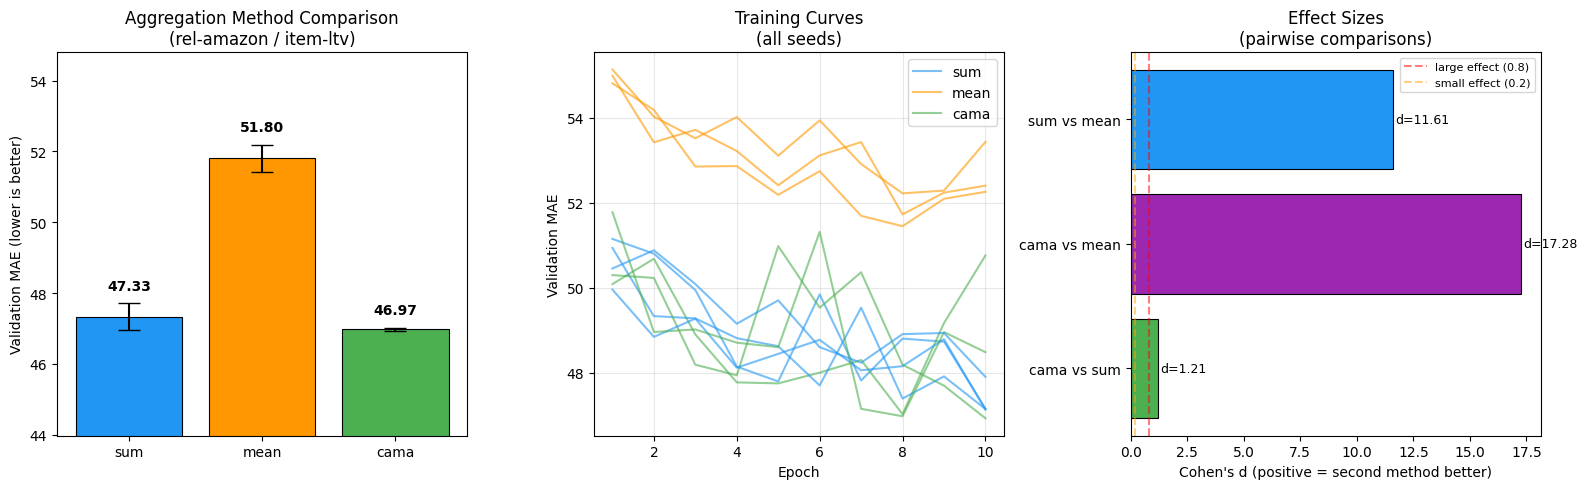


Key findings from the experiment:
  - CAMA outperforms sum on rel-amazon__item-ltv (mae): d=1.205
  - CAMA vs mean on rel-amazon__item-ltv: d=17.280
  - Sum vs mean on rel-amazon__item-ltv: d=11.611


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: MAE comparison bar chart ---
ax = axes[0]
methods = ['sum', 'mean', 'cama']
colors = ['#2196F3', '#FF9800', '#4CAF50']
means = [np.mean(method_scores[m]) for m in methods]
stds = [np.std(method_scores[m], ddof=1) if len(method_scores[m]) > 1 else 0 for m in methods]
bars = ax.bar(methods, means, yerr=stds, color=colors, capsize=8, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Validation MAE (lower is better)')
ax.set_title('Aggregation Method Comparison\n(rel-amazon / item-ltv)')
ax.set_ylim(bottom=min(means) - 3, top=max(means) + 3)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.3,
            f'{m:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Plot 2: Training curves (val MAE over epochs) ---
ax = axes[1]
method_colors = {'sum': '#2196F3', 'mean': '#FF9800', 'cama': '#4CAF50'}
plotted_labels = set()
for run in data['all_run_results']:
    method = run.get('method', '')
    epochs_data = run.get('epoch_records', [])
    if not epochs_data:
        continue
    ep = [e['epoch'] for e in epochs_data]
    val = [e['val_metric'] for e in epochs_data]
    seed = run.get('seed', 0)
    label = method if method not in plotted_labels else None
    ax.plot(ep, val, color=method_colors.get(method, 'gray'),
            alpha=0.6, linewidth=1.5, label=label)
    plotted_labels.add(method)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation MAE')
ax.set_title('Training Curves\n(all seeds)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Cohen's d effect sizes ---
ax = axes[2]
comp_names = []
comp_ds = []
comp_colors_plot = []
for name, color in [('cama_vs_sum', '#4CAF50'), ('cama_vs_mean', '#9C27B0'), ('sum_vs_mean', '#2196F3')]:
    if name in comparisons:
        comp_names.append(name.replace('_', ' '))
        comp_ds.append(comparisons[name]['cohens_d'])
        comp_colors_plot.append(color)

if comp_ds:
    y_pos = range(len(comp_names))
    bars = ax.barh(y_pos, comp_ds, color=comp_colors_plot, edgecolor='black', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_names)
    ax.set_xlabel("Cohen's d (positive = second method better)")
    ax.set_title("Effect Sizes\n(pairwise comparisons)")
    ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='large effect (0.8)')
    ax.axvline(x=0.2, color='orange', linestyle='--', alpha=0.5, label='small effect (0.2)')
    for bar, d in zip(bars, comp_ds):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'd={d:.2f}', ha='left', va='center', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nKey findings from the experiment:")
for finding in data.get('key_findings', []):
    print(f"  - {finding}")